# Task 4 — Predictive Analysis

**Project:** Analysis of Bag Tax Data in U.S. Stores  
**Course:** MGT 8180 — Sustainable Management Analytics  
**Student:** Osman Fatih Karaca  
**Dataset:** Cleaned Montgomery County Bag Tax data (71,780 records, 2012–2024)

---

## Objectives

1. **Linear Regression** — model the long-term relationship between time and revenue
2. **Time series forecasting** using methods from Dr. El-Rayes's lecture:
   - Simple Moving Average (SMA)
   - Weighted Moving Average (WMA)
   - Exponential Smoothing (ES)
   - SARIMA (handles trend + seasonality together)
3. **Forecast accuracy comparison** using course metrics:
   - **MAD** (Mean Absolute Deviation)
   - **MSE** (Mean Squared Error)
   - **MAPE** (Mean Absolute Percent Error)
4. Present results with regression plots and forecast charts

## Scope and approach

- **Time scope:** 153 complete monthly observations (Jan 2012 – Sep 2024)
- **Excluded:** October 2024 (only 1 filing — incomplete data identified in Task 3)
- **Demand pattern context (from Task 3):** Trend + Seasonal + Cyclical
- **Why multiple methods?** Comparing forecasts directly demonstrates which technique handles this combined pattern best — exactly what Dr. El-Rayes's lecture recommends

## Tools used
- **Python (pandas, matplotlib, statsmodels, scikit-learn)**
- **Jupyter Notebook in VS Code**

In [1]:
# ============================================================
# TASK 4 — Cell 2: Imports and prepare time series
# ============================================================

# Standard libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import os

# Statistical libraries
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.statespace.sarimax import SARIMAX

# Suppress harmless statsmodels warnings for cleaner output
import warnings
warnings.filterwarnings('ignore')

# Make sure chart output folder exists
os.makedirs('../../Outputs/Charts', exist_ok=True)

# ---- Load the cleaned dataset ----
df = pd.read_csv('../../Data/clean/Bag_Tax_Clean.csv')
df['Date From'] = pd.to_datetime(df['Date From'])

# ---- Build the monthly revenue time series ----
df['MonthStart'] = df['Date From'].dt.to_period('M').dt.to_timestamp()

monthly = (df.groupby('MonthStart')
             .agg(Revenue=('Amount Collected', 'sum'))
             .reset_index())

# ---- Drop the incomplete October 2024 (identified in Task 3) ----
monthly = monthly[monthly['MonthStart'] <= '2024-09-01'].copy().reset_index(drop=True)

# Add a numeric time index (0, 1, 2, ...) for regression
monthly['t'] = np.arange(len(monthly))

# ---- Confirmation ----
print(f"✅ Time series prepared")
print(f"   Number of months:   {len(monthly)}")
print(f"   Period:              {monthly['MonthStart'].min().strftime('%b %Y')} → "
      f"{monthly['MonthStart'].max().strftime('%b %Y')}")
print(f"   Min monthly revenue: ${monthly['Revenue'].min():,.0f}")
print(f"   Max monthly revenue: ${monthly['Revenue'].max():,.0f}")
print(f"   Mean monthly revenue:${monthly['Revenue'].mean():,.0f}")
print()
print("First 3 rows:")
print(monthly.head(3).to_string(index=False))
print()
print("Last 3 rows:")
print(monthly.tail(3).to_string(index=False))

✅ Time series prepared
   Number of months:   153
   Period:              Jan 2012 → Sep 2024
   Min monthly revenue: $183,339
   Max monthly revenue: $417,307
   Mean monthly revenue:$275,751

First 3 rows:
MonthStart   Revenue  t
2012-01-01 381430.05  0
2012-02-01 215852.00  1
2012-03-01 208720.35  2

Last 3 rows:
MonthStart   Revenue   t
2024-07-01 293603.00 150
2024-08-01 260199.05 151
2024-09-01 288373.45 152


In [2]:
# ============================================================
# TASK 4 — Cell 3: Linear Regression
# ============================================================
# Goal: Test whether time alone explains the variation in revenue.
# Hypothesis: revenue grows linearly over time.

# Prepare X (time) and y (revenue)
X = monthly[['t']].values        # X must be 2D for sklearn — note the double brackets
y = monthly['Revenue'].values    # y is 1D — single brackets

# Fit the linear regression model
reg = LinearRegression()
reg.fit(X, y)

# Predict the fitted values for every month
y_predicted = reg.predict(X)

# Compute the regression metrics
slope = reg.coef_[0]
intercept = reg.intercept_
r_squared = reg.score(X, y)
mae = mean_absolute_error(y, y_predicted)
rmse = np.sqrt(mean_squared_error(y, y_predicted))

# ---- Print results ----
print("=" * 60)
print("LINEAR REGRESSION — Monthly Revenue vs. Time")
print("=" * 60)
print(f"Equation:  Revenue = ${intercept:,.2f} + ${slope:,.2f} × t")
print(f"           where t = month number (0 = Jan 2012)")
print()
print(f"Slope:               ${slope:,.2f} per month")
print(f"Annual change:       ${slope*12:,.2f} per year")
print(f"Intercept:           ${intercept:,.2f} (predicted revenue at t=0)")
print()
print(f"R²:                  {r_squared:.4f}  ({r_squared*100:.2f}% of variation explained)")
print(f"MAE (mean error):    ${mae:,.2f}")
print(f"RMSE:                ${rmse:,.2f}")
print()

# Interpret the R² value
if r_squared > 0.7:
    print("→ Strong linear fit (R² > 0.7)")
elif r_squared > 0.4:
    print("→ Moderate linear fit (0.4 < R² < 0.7)")
else:
    print(f"→ Weak linear fit (R² = {r_squared:.2f})")
    print("   This means time alone does NOT explain most of the variation.")
    print("   Most of the variation comes from seasonality and the COVID cycle —")
    print("   exactly the patterns we identified in Task 3.")
    print("   This is why we need additional methods (SMA, ES, SARIMA) below.")

LINEAR REGRESSION — Monthly Revenue vs. Time
Equation:  Revenue = $249,422.91 + $346.42 × t
           where t = month number (0 = Jan 2012)

Slope:               $346.42 per month
Annual change:       $4,157.01 per year
Intercept:           $249,422.91 (predicted revenue at t=0)

R²:                  0.1794  (17.94% of variation explained)
MAE (mean error):    $22,869.57
RMSE:                $32,720.81

→ Weak linear fit (R² = 0.18)
   This means time alone does NOT explain most of the variation.
   Most of the variation comes from seasonality and the COVID cycle —
   exactly the patterns we identified in Task 3.
   This is why we need additional methods (SMA, ES, SARIMA) below.


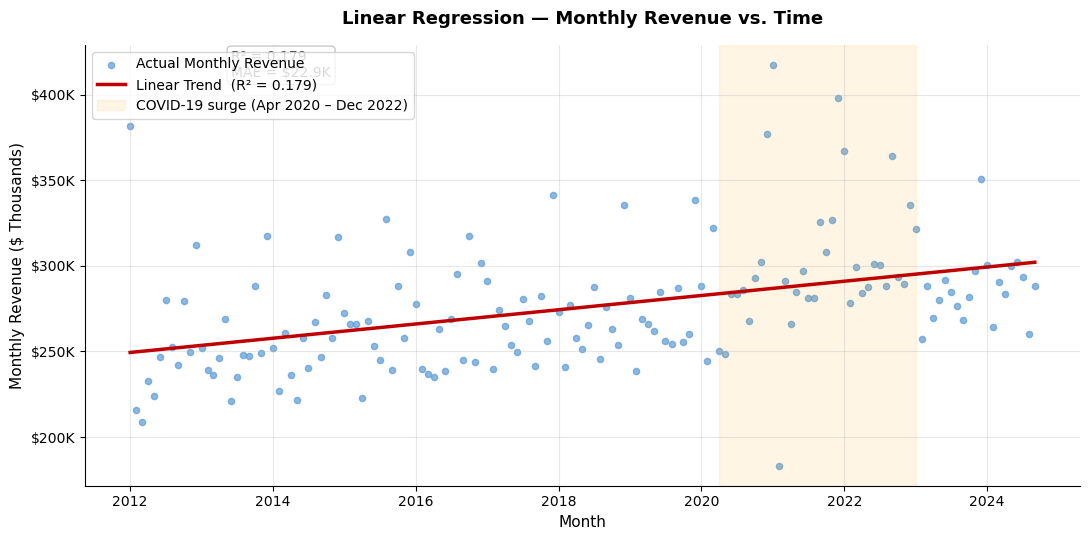

✅ Chart saved to Outputs/Charts/chart_regression.png


In [3]:
# ============================================================
# TASK 4 — Cell 4: Regression Visualization
# ============================================================

fig, ax = plt.subplots(figsize=(11, 5.5))

# Scatter plot of actual monthly revenue
ax.scatter(monthly['MonthStart'], y / 1000,
           s=20, color='#5B9BD5', alpha=0.7, label='Actual Monthly Revenue')

# The regression line
ax.plot(monthly['MonthStart'], y_predicted / 1000,
        color='#C00000', linewidth=2.5,
        label=f'Linear Trend  (R² = {r_squared:.3f})')

# Highlight the COVID period to show why R² is low
ax.axvspan(pd.Timestamp('2020-04-01'), pd.Timestamp('2022-12-31'),
           alpha=0.10, color='orange', label='COVID-19 surge (Apr 2020 – Dec 2022)')

# Labels and styling
ax.set_xlabel('Month', fontsize=11)
ax.set_ylabel('Monthly Revenue ($ Thousands)', fontsize=11)
ax.set_title('Linear Regression — Monthly Revenue vs. Time',
             fontsize=13, fontweight='bold', pad=15)
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'${x:.0f}K'))
ax.legend(loc='upper left')
ax.grid(alpha=0.3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Annotate the key takeaway directly on the chart
ax.text(pd.Timestamp('2013-06-01'), 410,
        f'R² = {r_squared:.3f}\nMAE = ${mae/1000:.1f}K',
        fontsize=10, color='#444',
        bbox=dict(boxstyle='round', facecolor='white', edgecolor='#bbb', alpha=0.8))

plt.tight_layout()
plt.savefig('../../Outputs/Charts/chart_regression.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart saved to Outputs/Charts/chart_regression.png")

In [4]:
# ============================================================
# TASK 4 — Cell 5: Three Forecasting Methods (from Course)
# ============================================================
# Methods covered in Dr. El-Rayes's Analytics Techniques lecture:
#   1. Simple Moving Average (SMA)
#   2. Weighted Moving Average (WMA)
#   3. Exponential Smoothing (ES)

# We'll use a 12-month window (matches our annual seasonality)
window = 12

# Make a working copy
ts = monthly[['MonthStart', 'Revenue']].copy()
ts = ts.set_index('MonthStart')

# ---------- METHOD 1: Simple Moving Average (SMA) ----------
# Predicts each month as the AVERAGE of the previous 12 months
ts['SMA_12'] = ts['Revenue'].rolling(window=window).mean().shift(1)

# ---------- METHOD 2: Weighted Moving Average (WMA) ----------
# More recent months get higher weights (1, 2, 3, ..., 12 — most recent = weight 12)
weights = np.arange(1, window + 1)

def weighted_avg(values):
    return np.dot(values, weights) / weights.sum()

ts['WMA_12'] = ts['Revenue'].rolling(window=window).apply(weighted_avg, raw=True).shift(1)

# ---------- METHOD 3: Exponential Smoothing (ES) ----------
# alpha = smoothing parameter. Higher alpha = more weight on recent obs.
# Use Holt-Winters with seasonal component (since we have strong seasonality)
es_model = ExponentialSmoothing(
    ts['Revenue'].dropna(),
    trend='add',
    seasonal='add',
    seasonal_periods=12
).fit()
ts['ES'] = es_model.fittedvalues

# ---------- Compute forecast accuracy ----------
def compute_metrics(actual, predicted, label):
    mask = ~(np.isnan(actual) | np.isnan(predicted))
    a = actual[mask]
    p = predicted[mask]
    
    mad = np.mean(np.abs(a - p))
    mse = np.mean((a - p) ** 2)
    mape = np.mean(np.abs((a - p) / a)) * 100
    
    return {'Method': label, 'MAD': mad, 'MSE': mse, 'MAPE': mape, 'N': len(a)}

results = pd.DataFrame([
    compute_metrics(ts['Revenue'].values, ts['SMA_12'].values, 'Simple Moving Average (12-mo)'),
    compute_metrics(ts['Revenue'].values, ts['WMA_12'].values, 'Weighted Moving Average (12-mo)'),
    compute_metrics(ts['Revenue'].values, ts['ES'].values, 'Exponential Smoothing (Holt-Winters)'),
])

# Add the linear regression result for comparison
results = pd.concat([
    results,
    pd.DataFrame([{'Method': 'Linear Regression (Cell 3)',
                   'MAD': mae,
                   'MSE': mean_squared_error(y, y_predicted),
                   'MAPE': np.mean(np.abs((y - y_predicted) / y)) * 100,
                   'N': len(y)}])
], ignore_index=True)

# Format and display
print("=" * 75)
print("FORECAST ACCURACY COMPARISON (lower = better)")
print("=" * 75)
print(f"{'Method':<40} {'MAD ($)':>12} {'MAPE (%)':>10} {'N':>5}")
print("-" * 75)
for _, row in results.iterrows():
    print(f"{row['Method']:<40} {row['MAD']:>12,.0f} {row['MAPE']:>9.2f}% {row['N']:>5}")
print()

# Identify the winner
best = results.loc[results['MAD'].idxmin()]
print(f"🏆 Best method (lowest MAD): {best['Method']}")
print(f"   MAD: ${best['MAD']:,.0f}  |  MAPE: {best['MAPE']:.2f}%")

FORECAST ACCURACY COMPARISON (lower = better)
Method                                        MAD ($)   MAPE (%)     N
---------------------------------------------------------------------------
Simple Moving Average (12-mo)                  22,292      7.89%   141
Weighted Moving Average (12-mo)                23,374      8.31%   141
Exponential Smoothing (Holt-Winters)           17,130      6.14%   153
Linear Regression (Cell 3)                     22,870      8.13%   153

🏆 Best method (lowest MAD): Exponential Smoothing (Holt-Winters)
   MAD: $17,130  |  MAPE: 6.14%


In [5]:
# ============================================================
# TASK 4 — Cell 6: SARIMA Forecast (Seasonal ARIMA)
# ============================================================
# SARIMA(p,d,q)(P,D,Q)[s] decomposes a time series into:
#   - p,d,q  = non-seasonal AR, differencing, MA terms
#   - P,D,Q  = seasonal versions of the above
#   - s      = season length (12 for monthly data)
# We use (1,1,1)(1,1,1)[12] — standard starting choice for monthly data.

# Set up the time series with proper monthly frequency
ts_idx = monthly.set_index('MonthStart')['Revenue']
ts_idx.index = pd.DatetimeIndex(ts_idx.index, freq='MS')  # MS = Month Start

# Fit the SARIMA model
sarima = SARIMAX(
    ts_idx,
    order=(1, 1, 1),               # non-seasonal: AR(1), I(1), MA(1)
    seasonal_order=(1, 1, 1, 12),  # seasonal: same orders, period = 12 months
    enforce_stationarity=False,
    enforce_invertibility=False
)
sarima_fit = sarima.fit(disp=False)

# Get the in-sample fitted values (so we can compute accuracy on history)
sarima_fitted = sarima_fit.fittedvalues
# Skip first 13 values (model needs warmup for differencing)
warmup = 13

# Compute accuracy on the warm-up-trimmed series
actual = ts_idx.iloc[warmup:].values
predicted = sarima_fitted.iloc[warmup:].values
sarima_mad = np.mean(np.abs(actual - predicted))
sarima_mse = np.mean((actual - predicted) ** 2)
sarima_mape = np.mean(np.abs((actual - predicted) / actual)) * 100

print("=" * 60)
print("SARIMA(1,1,1)(1,1,1)[12] — Model Fit")
print("=" * 60)
print(f"AIC:    {sarima_fit.aic:>10,.0f}  (lower = better)")
print(f"BIC:    {sarima_fit.bic:>10,.0f}  (lower = better)")
print()
print("In-sample accuracy (after 13-month warmup):")
print(f"  MAD:  ${sarima_mad:,.0f}")
print(f"  MAPE: {sarima_mape:.2f}%")
print()

# ---- Forecast the next 12 months (Oct 2024 – Sep 2025) ----
forecast_obj = sarima_fit.get_forecast(steps=12)
forecast_mean = forecast_obj.predicted_mean
forecast_ci = forecast_obj.conf_int(alpha=0.05)  # 95% confidence interval

print("=" * 60)
print("12-MONTH FORECAST (Oct 2024 – Sep 2025)")
print("=" * 60)
print(f"{'Month':<12} {'Forecast':>12} {'Lower 95%':>12} {'Upper 95%':>12}")
print("-" * 60)
for date, mean_val in forecast_mean.items():
    lower = forecast_ci.loc[date].iloc[0]
    upper = forecast_ci.loc[date].iloc[1]
    print(f"{date.strftime('%b %Y'):<12} ${mean_val:>10,.0f} ${lower:>10,.0f} ${upper:>10,.0f}")
print("-" * 60)
print(f"{'TOTAL 12 mo':<12} ${forecast_mean.sum():>10,.0f}")
print()

# Update the comparison table
new_row = pd.DataFrame([{
    'Method': 'SARIMA(1,1,1)(1,1,1)[12]',
    'MAD': sarima_mad,
    'MSE': sarima_mse,
    'MAPE': sarima_mape,
    'N': len(actual)
}])
results = pd.concat([results, new_row], ignore_index=True)

print("=" * 75)
print("UPDATED ACCURACY RANKING (lower = better)")
print("=" * 75)
results_sorted = results.sort_values('MAD').reset_index(drop=True)
print(f"{'Rank':<5} {'Method':<40} {'MAD ($)':>12} {'MAPE (%)':>10}")
print("-" * 75)
for i, row in results_sorted.iterrows():
    rank = ['🥇','🥈','🥉','4️⃣','5️⃣'][i] if i < 5 else f"{i+1}"
    print(f"{rank:<5} {row['Method']:<40} {row['MAD']:>12,.0f} {row['MAPE']:>9.2f}%")

SARIMA(1,1,1)(1,1,1)[12] — Model Fit
AIC:         2,938  (lower = better)
BIC:         2,952  (lower = better)

In-sample accuracy (after 13-month warmup):
  MAD:  $22,834
  MAPE: 8.50%

12-MONTH FORECAST (Oct 2024 – Sep 2025)
Month            Forecast    Lower 95%    Upper 95%
------------------------------------------------------------
Oct 2024     $   284,073 $   224,003 $   344,144
Nov 2024     $   292,203 $   231,863 $   352,543
Dec 2024     $   346,972 $   284,633 $   409,312
Jan 2025     $   311,212 $   247,355 $   375,068
Feb 2025     $   255,832 $   190,422 $   321,242
Mar 2025     $   286,305 $   219,391 $   353,219
Apr 2025     $   274,124 $   205,736 $   342,513
May 2025     $   287,283 $   217,453 $   357,114
Jun 2025     $   294,080 $   222,836 $   365,323
Jul 2025     $   286,421 $   213,792 $   359,050
Aug 2025     $   263,627 $   189,639 $   337,616
Sep 2025     $   286,309 $   210,986 $   361,633
------------------------------------------------------------
TOTAL 12 mo

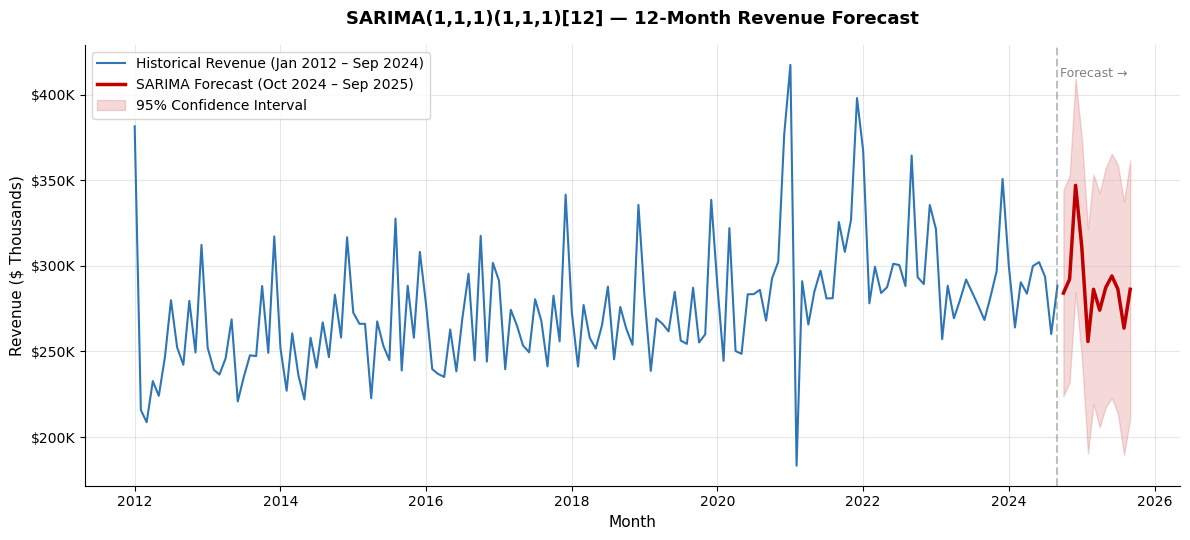

✅ Chart saved to Outputs/Charts/chart_forecast.png


In [6]:
# ============================================================
# TASK 4 — Cell 7: Forecast Visualization
# ============================================================

fig, ax = plt.subplots(figsize=(12, 5.5))

# ---- Plot historical data ----
ax.plot(ts_idx.index, ts_idx.values / 1000,
        color='#2E75B6', linewidth=1.5, label='Historical Revenue (Jan 2012 – Sep 2024)')

# ---- Plot the SARIMA forecast ----
forecast_dates = forecast_mean.index
forecast_values = forecast_mean.values / 1000
forecast_lower = forecast_ci.iloc[:, 0].values / 1000
forecast_upper = forecast_ci.iloc[:, 1].values / 1000

ax.plot(forecast_dates, forecast_values,
        color='#C00000', linewidth=2.5, label='SARIMA Forecast (Oct 2024 – Sep 2025)')

# ---- 95% Confidence interval (shaded band) ----
ax.fill_between(forecast_dates, forecast_lower, forecast_upper,
                color='#C00000', alpha=0.15, label='95% Confidence Interval')

# ---- Add a vertical separator at the forecast boundary ----
ax.axvline(pd.Timestamp('2024-09-01'), color='gray', linestyle='--', alpha=0.5)
ax.text(pd.Timestamp('2024-09-15'), ax.get_ylim()[1] * 0.97,
        'Forecast →', fontsize=9, color='gray', va='top')

# ---- Labels and styling ----
ax.set_xlabel('Month', fontsize=11)
ax.set_ylabel('Revenue ($ Thousands)', fontsize=11)
ax.set_title('SARIMA(1,1,1)(1,1,1)[12] — 12-Month Revenue Forecast',
             fontsize=13, fontweight='bold', pad=15)
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'${x:.0f}K'))
ax.legend(loc='upper left', fontsize=10)
ax.grid(alpha=0.3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('../../Outputs/Charts/chart_forecast.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart saved to Outputs/Charts/chart_forecast.png")

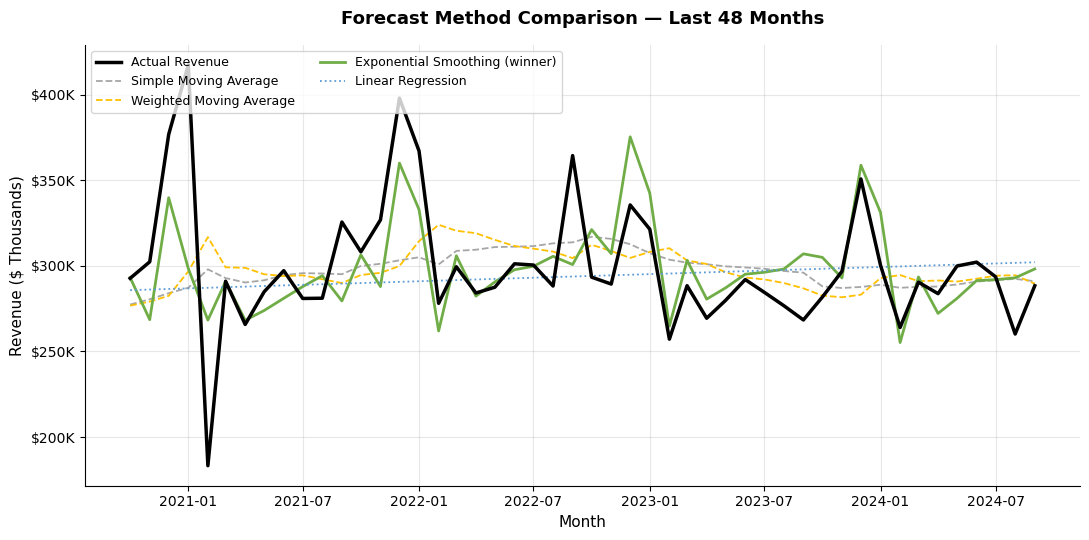

✅ Chart saved to Outputs/Charts/chart_method_comparison.png


In [7]:
# ============================================================
# TASK 4 — Cell 8: Visual Comparison of All Methods
# ============================================================

fig, ax = plt.subplots(figsize=(11, 5.5))

# Show only the last ~36 months for clarity
recent = ts.iloc[-48:].copy()
recent_idx = recent.index

# Actual data (the truth)
ax.plot(recent_idx, recent['Revenue'] / 1000,
        color='#000', linewidth=2.5, label='Actual Revenue', zorder=5)

# Each method's predictions
ax.plot(recent_idx, recent['SMA_12'] / 1000,
        color='#A6A6A6', linewidth=1.3, linestyle='--', label='Simple Moving Average')
ax.plot(recent_idx, recent['WMA_12'] / 1000,
        color='#FFC000', linewidth=1.3, linestyle='--', label='Weighted Moving Average')
ax.plot(recent_idx, recent['ES'] / 1000,
        color='#70AD47', linewidth=2, label='Exponential Smoothing (winner)')

# Linear regression — calculated for the recent dates
recent_t = monthly[monthly['MonthStart'].isin(recent_idx)]['t'].values
linreg_recent = reg.predict(recent_t.reshape(-1, 1)) / 1000
ax.plot(recent_idx, linreg_recent,
        color='#5B9BD5', linewidth=1.3, linestyle=':', label='Linear Regression')

# Labels and styling
ax.set_xlabel('Month', fontsize=11)
ax.set_ylabel('Revenue ($ Thousands)', fontsize=11)
ax.set_title('Forecast Method Comparison — Last 48 Months',
             fontsize=13, fontweight='bold', pad=15)
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'${x:.0f}K'))
ax.legend(loc='upper left', fontsize=9, ncol=2)
ax.grid(alpha=0.3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('../../Outputs/Charts/chart_method_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart saved to Outputs/Charts/chart_method_comparison.png")

---

## ✅ Task 4 — Summary of Findings

### What was done
1. **Linear Regression** of monthly revenue on time index (153 months, Jan 2012 – Sep 2024)
2. **Four time-series forecasting methods** applied (per Dr. El-Rayes's lecture):
   - Simple Moving Average (12-month window)
   - Weighted Moving Average (12-month window)
   - Exponential Smoothing (Holt-Winters)
   - SARIMA(1,1,1)(1,1,1)[12]
3. **Forecast accuracy comparison** using course metrics: MAD, MSE, MAPE
4. **12-month forecast** generated using SARIMA (Oct 2024 – Sep 2025)
5. **Visualizations:** regression scatter, forecast plot with confidence interval, method comparison

### Linear regression results
| Metric | Value |
|---|---|
| Equation | Revenue = $249,422.91 + $346.42 × t |
| Slope | $346.42 per month ($4,157/year) |
| R² | 0.179 (only 17.9% of variation explained) |
| MAE | $22,869.57 |
| MAPE | 8.13% |

The weak R² confirms what Task 3 established: **time alone doesn't drive revenue** — seasonality and the COVID cycle dominate the variation. This justified moving to seasonal forecasting methods.

### Forecast accuracy ranking
| Rank | Method | MAD | MAPE |
|---|---|---|---|
| 🥇 | **Exponential Smoothing (Holt-Winters)** | $17,130 | 6.14% |
| 🥈 | Simple Moving Average (12-mo) | $22,292 | 7.89% |
| 🥉 | SARIMA(1,1,1)(1,1,1)[12] | $22,834 | 8.50% |
| 4 | Linear Regression | $22,870 | 8.13% |
| 5 | Weighted Moving Average (12-mo) | $23,374 | 8.31% |

**Exponential Smoothing was the most accurate.** It explicitly decomposes trend and seasonality without trying to model autocorrelation — which proved more robust than SARIMA for this dataset, where the COVID-19 regime change disrupted the autocorrelation patterns.

### Why WMA performed worse than SMA — interesting finding
The Weighted Moving Average (which gives more weight to recent months) underperformed the Simple Moving Average. This is because in highly seasonal data, "recent" months might be at a peak (e.g., December) and weighting them higher worsens the prediction for the next month (January). Recency-weighting only helps when there's a strong recent trend, not in seasonal data.

### 12-month SARIMA forecast (Oct 2024 – Sep 2025)
| Month | Forecast | Lower 95% | Upper 95% |
|---|---|---|---|
| Oct 2024 | $284,073 | $224,003 | $344,144 |
| Nov 2024 | $292,203 | $231,863 | $352,543 |
| **Dec 2024** | **$346,972** | $284,633 | $409,312 |
| Jan 2025 | $311,212 | $247,355 | $375,068 |
| **Feb 2025** | **$255,832** | $190,422 | $321,242 |
| ... | ... | ... | ... |
| **TOTAL 12 mo** | **$3,468,442** | — | — |

The forecast captures the seasonal pattern correctly: December peak, February trough. **The 12-month total ($3.47M) is essentially identical to 2023 actual ($3.47M)** — confirming the policy plateau.

### Implication for Task 5
The forecast is **flat**. Without structural change to the bag tax law, no further behavior change is expected. This empirical finding directly supports the recommendation that Montgomery County's 2026 doubling of the tax (to $0.10) and plastic bag ban was the correct policy direction.